# Connectomics Module 1: Neuron-centered connectomics

The function of the nervous system arises out of a combination of the properties of individual neurons and the properties of how they are connected into a larger network. The central goal of <b>connectomics</b> is to produce complete maps of the connectivity of the nervous system with synaptic resolution and analyze them to better understand the organization, development, and function of the nervous system.

Electron Microscopy (EM) data enables morphological reconstruction of neurons and resolution of their synaptic connectivity </b>. The V1DD dataset is one of the largest volume EM datasets currently available, and spans all layers of mouse visual cortex. We will be using this dataset to query the connectivity between neurons in the visual cortex.

The V1DD dataset is newly public. </b> Previous years of this course have used the [MICrONS Dataset](https://www.microns-explorer.org/), which is also a cubic millimeter volume of mouse visual cortex. Both datasets are available for the use of this course, but we will cover V1DD in Week 1.

Module 1 of this workshop will:

* introduce the basics of how synaptic connectivity is measured in EM connectomics
* examine reconstructions of individual neurons and their connectivity
* discuss how morphological features and connectivity suggest cell types
* explore how connectivity changes as function of target and distance

Module 2 of this workshop will:

* introduce concepts of network connectivity
* investigate the role of cell type in the structure of networks
* consider connection probability as a function of distance
* incorporate ophys recordings and map the correlation of structure to function


## Setup

Where the data lives depends on where you are running: `/data/` on CodeOcean, the
Brain2026 drive at the workshop, a `data/` folder in a local checkout. `utils/paths.py`
walks that ladder — `SWDB_DATA_ROOT` if you set it, then a repo-local `data/`, then the
platform default — and fails with the list of paths it tried if none exist. Read its
docstring if a path ever surprises you.

In [1]:
# Import packages
import pandas as pd
import numpy as np

import ossify as osy
from standard_transform.datasets import v1dd_ds

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

/opt/conda/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.2) or chardet (7.6.0)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


## CAVE account setup

In order to manage server traffic, every user needs to create a CAVE account and download a user token to access CAVE's services programmatically. The CAVE infrastructure can be read about in more detail in the [MICrONS Nature Package](https://doi.org/10.1038/s41592-024-02426-z).

**A Google account (or Google-enabled account) is required to create a CAVE account.**

Run the cell below and follow the set up instructions; enter the token first, then enter 'y' when prompted

In [2]:
from caveclient import CAVEclient

# Token Generation and Setup
CAVEclient.setup_token("https://global.em.brain.allentech.org")

# Initialize CAVEclient
client = CAVEclient(datastack_name="v1dd_public")

Visit https://global.em.brain.allentech.org/sticky_auth/settings/tokens and copy an existing token or create a new one.


Paste your auth token (input will be hidden):  ········
Set all of your datastacks to use this token and server ('Y', recommended), specify individual datastacks ('n'), or finish now ('exit'). (Y/n/exit)  y


All datastacks are configured to use this server address.
You will not need to specify a server address when initializing a client for configured datastacks in the future.
Setup complete!


**Tip for CodeOcean users:** you can add the the CAVEclient token to your capsule's secrets, so you do not have to enter it every time you run the notebook. If you chose to use EM data for your project in Week 2, [check out the DataBook for instruction](https://allenswdb.github.io/anatomy/microns-em/em-caveclient-setup.html#codeocean-token-setup)

## Neuron morphology: representing neurons as skeletons

Often in thinking about neurons, you want to measure things along a linear dimension of a neuron.

However, the segmentation and meshes are a complex 3D shape that makes this non-trivial. There are methods for reducing the shape of a segmented neuron down to a linear tree like structure usually referred to as a **skeleton**. CAVE `Skeleton Service` automatically generates skeletons for a large number of cells in the dataset, and make the skeleton generation available on demand.

![Skeleton representation of neuron topology](img/swdb_mesh_skeleton.png)

*Note*: The meshes you see in Neuroglancer are available to download through the python client `cloud-volume`, and can be loaded for analysis and visualization in other tools. This is useful for some types of analysis (and for making beautiful renders of neurons), but we will not cover that in this course.

Now we will select one neuron based on its root_id, the 18-digit number you see in neuroglancer (like we will do later)

In [3]:
# Load basic cell (skeleton + L2 graph)
root_id = 864691132534315610 # Known example neuron. You may iterate later. 

cell = osy.load_cell_from_client(
    root_id=root_id,
    client=client,
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")

Loaded cell 864691132534315610
Skeleton: 3567 vertices


The python package `ossify` provides skeleton downloading, processing, analysis, and many convenience functions. Including loading cells directly from connectomics databases using CAVEclient. For documentation, see [Ossify](https://csdashm.com/ossify/).

Then we can use the `plot_morphology_2d` function to visualize our neuron in two dimensions:

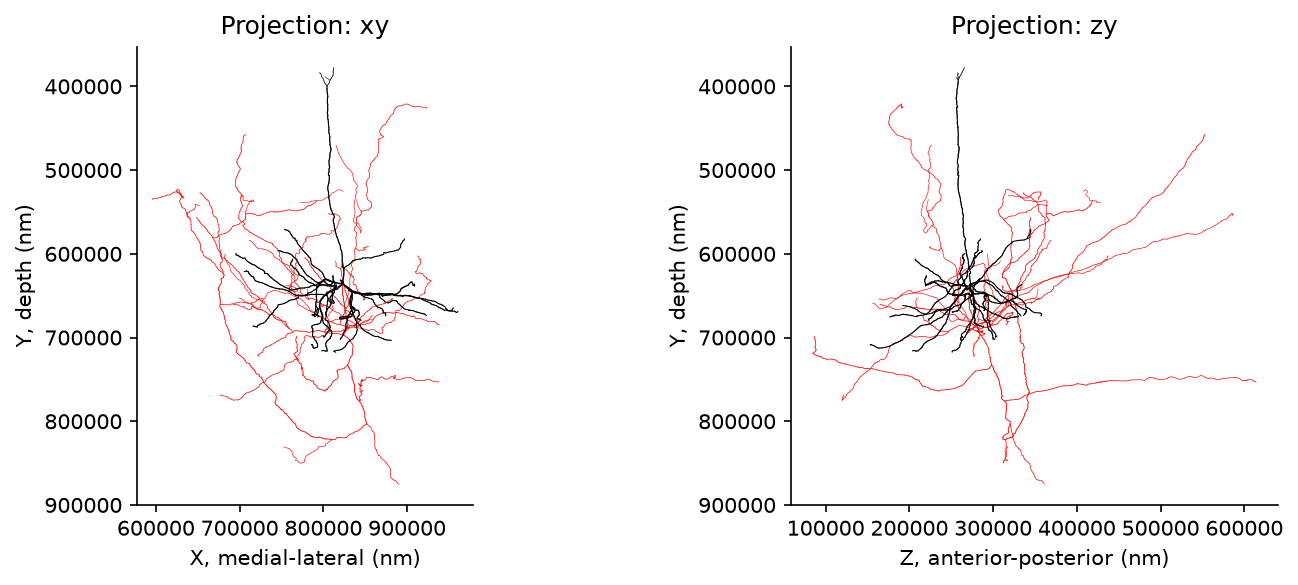

In [4]:
# Figure 1: Skeleton representation in 2D

# Plot different 2D projections
projections = ["xy", "zy"] # , 'xz']
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i, proj in enumerate(projections):
    osy.plot.plot_morphology_2d(
        cell,
        projection=proj,
        color="compartment",
        # Compartment codes are SWC conventions; use the names rather than 1/2/3
        palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
        linewidth="radius",          # thicker where the neurite is thicker
        linewidth_norm=(100, 1000),  # radii in nm that map to the width range below
        widths=(0.25, 2),
        ax=axes[i]
    )
    axes[i].set_title(f"Projection: {proj}")
    axes[i].set_aspect("equal")

# Add labels for the anatomical orientation
axes[0].set(xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
axes[1].set(xlabel='Z, anterior-posterior (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.tight_layout()
plt.show()

#### Transformed coordinate system

A note on the coordinate frame: the _native resolution_ for V1DD is in units of _voxels_. The data you will see in neuroglancer is in Voxel space where each coordinate is in the thousands. Not only are these units large, the offset is arbitrary.  we want a more comprehensible numbers for comparison. It makes much more sense to anchor y=0 to the pial surface and use 'real' coordinates.

The skeleton above is plotted in **nanometer coordinates**, which differs from neuroglancer. In general, there are three types of coordinates you may encounter and it is worth being deliberate in which system you use.

1. <b>Voxel coordinates</b> are the coordinates of a point in the original image volume. These are the coordinates that are used to index into the volumes you can see in Neuroglancer, but each number has a potentially different unit. In the V1DD data, a voxel is 9 nm wide in the x and y directions, and 45 nm long in the z direction. This means that a 1x1x1 micron cube would be represented by a ~110x110x20 voxel span. Annotations (such as synapses) are stored in voxel coordinates.
2. <b>Nanometer coordinates</b> are the coordinates of a point in the original image volume, but in nanometers. This is equivalent to the voxel coordinate multiplied by the voxel resolution, with no further transformation applied. Mesh and skeleton vertices are stored in nanometer coordinates.
3. <b>Transformed coordinates</b> reflect a transformation that has been applied to the original image volume. This transformation is a rotation to make the pia surface as flat as possible, a translation to move the pial surface to y=0, and a scaling to bring coordinates into microns. Transformed coordinates are convenient for more accurate computations of depth and the pia-to-white-matter axis, but are not stored by default.For documentation, see [Standard Transform](https://caveconnectome.github.io/standard_transform/).

You will encounter more neuron-centered representations of space later in the module.

Rather than take that on faith, apply the transform and plot the same cell again.
`v1dd_ds.transform("nm")` builds the transform for this dataset and declares that the *input*
coordinates are nanometers; `cell.transform(...)` returns a new cell with every
vertex moved, leaving the original untouched.

Compare the axes with Figure 1. The shape is the same — it is the same neuron — but the
numbers are now microns of depth below the pia, so "this synapse is at 250 µm" means
something anatomical rather than something about where the volume happened to be cropped.

Every figure from here on uses transformed coordinates.

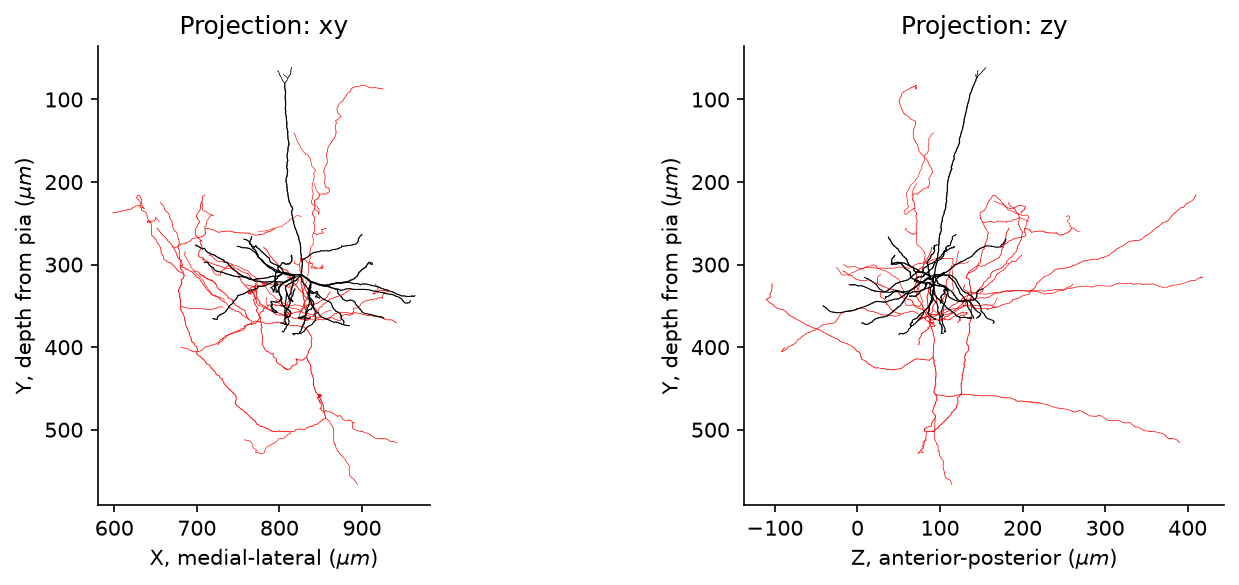

In [5]:
# Figure 1b: the same skeleton in transformed coordinates

# One transform object, reused for the rest of the notebook. "nm" says what goes in.
tform = v1dd_ds.transform("nm")

cell_um = cell.transform(tform.apply)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i, proj in enumerate(["xy", "zy"]):
    osy.plot.plot_morphology_2d(
        cell_um,
        projection=proj,
        color="compartment",
        palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
        linewidth="radius",
        linewidth_norm=(100, 1000),
        widths=(0.25, 2),
        ax=axes[i]
    )
    axes[i].set_title(f"Projection: {proj}")
    axes[i].set_aspect("equal")

axes[0].set(xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
axes[1].set(xlabel=r'Z, anterior-posterior ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
sns.despine()
plt.tight_layout()
plt.show()

### Adding synapse positions to skeleton

Synapses are automatically detected and assigned in the dataset. That means we know* all of the inputs to and outputs from our cell of interest. Let's collect that data:

**Note** this cell may take a minute to run. It is pulling more data than the previous code `load_cell` call

In [6]:
# Load skeleton with synaptic features
root_id = 864691132534315610 # Known example neuron. You may iterate later. 

cell = osy.load_cell_from_client(
    root_id=root_id,
    client=client,
    synapses=True, # optional argument to load synapses with skeleton
    include_partner_root_id=True, # optional argument to load partner root ids with synapses
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")

# All annotations in the cell
cell.annotations.describe()

Loaded cell 864691132534315610
Skeleton: 3567 vertices
# Annotations (2)
├── pre_syn (PointCloudLayer)
│   ├── 673 vertices
│   ├── features: [created, deleted, post_pt_position_x, post_pt_position_y, post_pt_position_z, post_pt_root_id, 
│       post_pt_supervoxel_id, pre_pt_l2_id, pre_pt_position_x, pre_pt_position_y, pre_pt_position_z, pre_pt_root_id, 
│       pre_pt_supervoxel_id, size]
│   └── Links: graph <-> pre_syn
└── post_syn (PointCloudLayer)
    ├── 1091 vertices
    ├── features: [created, deleted, post_pt_l2_id, post_pt_position_x, post_pt_position_y, post_pt_position_z, 
│       post_pt_root_id, post_pt_supervoxel_id, pre_pt_position_x, pre_pt_position_y, pre_pt_position_z, pre_pt_root_id, 
│       pre_pt_supervoxel_id, size]
    └── Links: graph <-> post_syn


In [ ]:
# Show the synapse dataframe attached to skeleton
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes

# return the available columns to line
print(pre_syn_df.columns)

pre_syn_df.head(3)

Index(['created', 'deleted', 'pre_pt_position_x', 'pre_pt_position_y',
       'pre_pt_position_z', 'post_pt_position_x', 'post_pt_position_y',
       'post_pt_position_z', 'ctr_pt_position_x', 'ctr_pt_position_y',
       'ctr_pt_position_z', 'size', 'pre_pt_supervoxel_id', 'pre_pt_root_id',
       'post_pt_supervoxel_id', 'post_pt_root_id', 'pre_pt_l2_id'],
      dtype='object')


,created,deleted,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_l2_id
id,,,,,,,,,,,,,,,,,
402558233,2021-11-18 22:05:28.270700+00:00,NaT,839602,564646,228735,839515,565160,229410,839699.0,565034.0,229095.0,3881.0,93320500256229717,864691132534315610,93320568975740637,864691132726874269,165378094293583076
292446107,2021-11-18 22:06:23.833563+00:00,NaT,675478,569525,361440,675333,569700,361125,675469.0,569603.0,361305.0,1082.0,88676300981986694,864691132534315610,88676300981976915,864691132620269499,160733895019463949
438169048,2021-11-18 22:08:20.896586+00:00,NaT,865899,475571,202005,865725,476095,202230,865695.0,475872.0,202005.0,5146.0,94021782449115055,864691132534315610,94021782449121473,864691132569299996,166079376486565024


#### Call back: consistent coordinate system transform

We'll apply the `standard_transform` now so it doesn't surprise us later

In [8]:
# Put the skeleton and the synapses in the same (transformed) space before plotting them together
cell_um = cell.transform(tform.apply)

# Synapse positions arrive in nanometers, same as the skeleton vertices, so they take the
# same transform. `ctr_pt_position` is the centre of the synapse; apply_dataframe finds
# the _x/_y/_z columns for us.
for df in (pre_syn_df, post_syn_df):
    df["syn_x_um"] = tform.apply_dataframe("ctr_pt_position", df, projection="x")
    df["syn_y_um"] = tform.apply_dataframe("ctr_pt_position", df, projection="y")
    df["syn_z_um"] = tform.apply_dataframe("ctr_pt_position", df, projection="z")

post_syn_df[["ctr_pt_position_x", "ctr_pt_position_y", "syn_x_um", "syn_y_um"]].head(3)

,ctr_pt_position_x,ctr_pt_position_y,syn_x_um,syn_y_um
id,,,,
405315773,830717.0,643333.0,834.118076,328.754625
395011063,815770.0,577247.0,818.812965,253.579560
440332672,872738.0,655322.0,876.195566,339.048801


### Examine the synapses for a cell of interest

Now we have all the synapses associated with this cell, where its `pt_root_id` shows up as either the *presynaptic* id or the *postsynaptic* id. The dataframe returned above includes a lot of bookkeeping columns we don't care about. We will narrow our focus down to 5 classes of column:

* `id` : the *synapse id* which is unique to every detected synapse and is immutable.  
* `pre_pt_root_id` , `post_pt_root_id` : the segmentation id or `root_id` for the object on either side of the synapse. This may be a neuron, a fragment of a neuron, or a non-neuronal object. This is the id unique to the segmentated object at that time, but will change with proofreading.  
* `size` : the size of the synaptic cleft in units of voxels. This is an output of the automated synapse detection, and is generally a useful low-level feature for other analysis.  
* `ctr_pt_position_x`, `ctr_pt_position_y`, `ctr_pt_position_z`: the mid-point position of the synapse in units of `nm`. The position metric we generally use, though two other types of position exist: `pre_pt` and `post_pt` which are useful if you need the point to land on either the presynaptic or postsynaptic segment, respectively.  
* `syn_x_um`, `syn_y_um`, `syn_z_um`: our applied transformation from standard_transform, putting the units in transformed_um.  


In [9]:
post_syn_df.head(3)[['pre_pt_root_id','post_pt_root_id','size','ctr_pt_position_x','ctr_pt_position_y','ctr_pt_position_z','syn_x_um','syn_y_um','syn_z_um']]

,pre_pt_root_id,post_pt_root_id,size,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,syn_x_um,syn_y_um,syn_z_um
id,,,,,,,,,
405315773,864691131677275322,864691132534315610,1707.0,830717.0,643333.0,308385.0,834.118076,328.754625,125.484344
395011063,864691132921086475,864691132534315610,465.0,815770.0,577247.0,265140.0,818.812965,253.579560,101.497568
440332672,864691132578941970,864691132534315610,933.0,872738.0,655322.0,304470.0,876.195566,339.048801,118.531462


In [10]:
pre_syn_df.head(3)[['pre_pt_root_id','post_pt_root_id','size','ctr_pt_position_x','ctr_pt_position_y','ctr_pt_position_z','syn_x_um','syn_y_um','syn_z_um']]

,pre_pt_root_id,post_pt_root_id,size,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,syn_x_um,syn_y_um,syn_z_um
id,,,,,,,,,
402558233,864691132534315610,864691132726874269,3881.0,839699.0,565034.0,229095.0,842.656411,232.044611,70.053451
292446107,864691132534315610,864691132620269499,1082.0,675469.0,569603.0,361305.0,678.540945,272.654867,196.104130
438169048,864691132534315610,864691132569299996,5146.0,865695.0,475872.0,202005.0,868.189882,138.756608,67.836993


#### Exercise 1: What is input or output? How can we tell?

Look at the two tables above. Both have a `pre_pt_root_id` and a `post_pt_root_id` column,
because a synapse is a directed thing: it runs *from* the presynaptic neuron *to* the
postsynaptic neuron. Neither column is "our" cell by definition — which one holds our
root id is exactly what tells us which direction we are looking at.

In the first table, `post_pt_root_id` is `864691132534315610` on every row: our cell is the one receiving. Those are its **inputs**. 

In the second, `pre_pt_root_id` is our cell on every row: it is the one sending. Those are its **outputs**.

The annotation ossify calls `post_syn` is the one
where our cell is the *post*synaptic partner — so `post_syn` holds the **inputs**, and
`pre_syn` holds the **outputs**. Read the name as "which side of the synapse our cell is
on", not "which direction the information flows". Getting this backwards silently swaps
every result in the rest of the notebook, and nothing will crash to tell you.

So we will give them unambiguous names, and then check rather than trust:

In [11]:
input_df = post_syn_df   # our cell is POSTsynaptic -> these are inputs
output_df = pre_syn_df   # our cell is PREsynaptic  -> these are outputs

#### Plot synapses on skeleton

Let's check your answer by plotting the synapse positions on the skeleton:

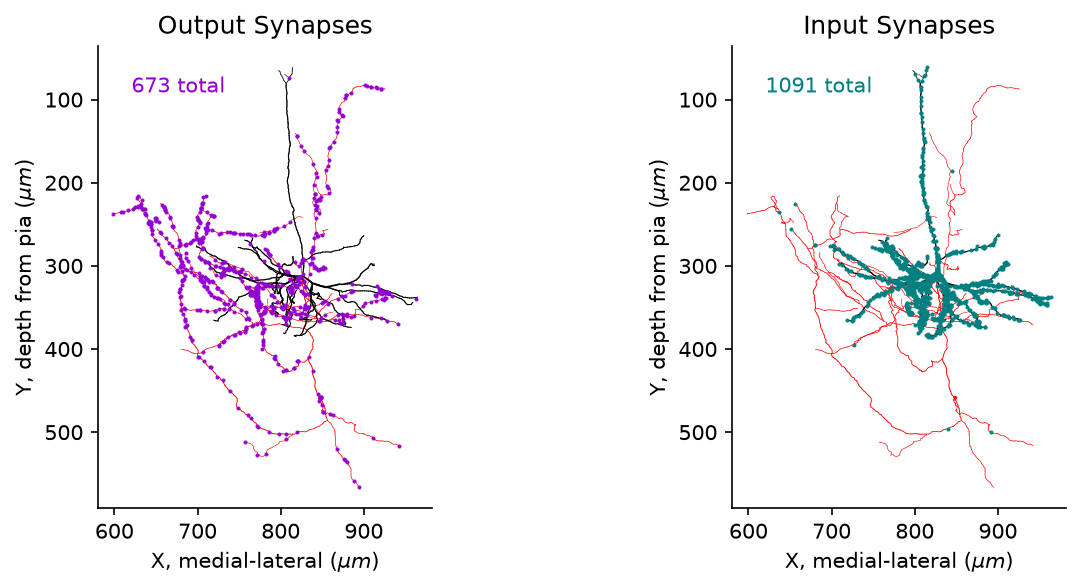

In [12]:
# Figure 2: Skeleton with synaptic inputs and outputs

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i in range(2):
    osy.plot.plot_morphology_2d(cell_um,
                                projection="xy",
                                color="compartment",
                                palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
                                linewidth="radius",
                                linewidth_norm=(100, 1000),
                                widths=(0.25, 2),
                                ax=ax[i])

# Output synapses
sns.scatterplot(data=output_df, x="syn_x_um", y="syn_y_um",
                s=3, color="darkviolet", ax=ax[0], edgecolor=None, zorder=100)
ax[0].text(.1,.9,f'{len(output_df)} total', color='darkviolet',  transform = ax[0].transAxes)


# Input synapses
sns.scatterplot(data=input_df, x="syn_x_um", y="syn_y_um",
                s=3, color="teal", ax=ax[1], edgecolor=None, zorder=100)
ax[1].text(.1,.9, f'{len(input_df)} total', color='teal',  transform = ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
ax[1].set(title="Input Synapses", xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')

sns.despine()
plt.show()

In [13]:
# Check the convention instead of trusting the name. Our cell should be the postsynaptic
# partner in every input row, and the presynaptic partner in every output row.
assert (input_df["post_pt_root_id"] == root_id).all()
assert (output_df["pre_pt_root_id"] == root_id).all()

print(f"{len(input_df):,} inputs, {len(output_df):,} outputs")

1,091 inputs, 673 outputs


**Tip for Student Project analysis**: We could also have gotten the same thing (synapses for our cell of interest) faster without getting the skeleton, as follows:

```
# Inputs synapses: Query synapse table with synapse_query()
post_syn_df = client.materialize.synapse_query(post_ids=root_id)

# Output synapses: Query synapse table with synapse_query()
pre_syn_df = client.materialize.synapse_query(pre_ids=root_id)

```

The `synapse_query` function allows you to query the synapse table in a more convenient way than most other tables.
In particular, the `pre_ids` and `post_ids` let you specify which root id (or collection of root ids) you want to query, with pre_ids indicating the collection of **presynaptic neurons** and post_ids the collection of **postsynaptic neurons**.

Using both `pre_ids` and `post_ids` in one call is effectively a logical AND, returning only those synapses from neurons in the list of `pre_ids` that target neurons in the list of `post_ids`.

### Aggregating synapses to unique connections

Note that synapse queries always return the list of every synapse between the neurons in the query, even if there are multiple synapses between the same pair of neurons.

A common pattern to generate a list of **connections** between unique pairs of neurons is to group by the root ids of the presynaptic and postsynaptic neurons and then count the number of synapses between them.
For example, use `pandas.groupby()` to get the number of synapses from this neuron onto every other neuron:

In [14]:
# get count of synapses between presynaptic and postsynaptic partners
output_connectivity = (output_df.groupby(['pre_pt_root_id', 'post_pt_root_id'])
 ["size"].agg(['count'])
 .rename(columns={'count': 'syn_count'})
 .sort_values( by='syn_count', ascending=False,)
)

output_connectivity
# Note that the 'size' part here is just a way to quickly extract one column. This could be any of the remaining column names.

syn_count
pre_pt_root_id     post_pt_root_id              
864691132534315610 864691132708393766          6
                   864691132748924877          5
                   864691132782212618          5
                   864691133066825032          5
                   864691132605839533          4
...                                          ...
                   864691132252788418          1
                   864691132266513468          1
                   864691132287392351          1
                   864691132292351470          1
                   864691132239320617          1

[601 rows x 1 columns]

#### Exercise 2: aggregate input connectivity

Copy paste to generate the 'input connectivity' instead of output connectivity. Which column is held constant?

In [15]:
# Same aggregation, but starting from the inputs. `post_pt_root_id` is the column held
# constant now: every input synapse lands on our cell, so it is the presynaptic partner
# that varies.
input_connectivity = (input_df.groupby(['pre_pt_root_id', 'post_pt_root_id'])
 ["size"].agg(['count'])
 .rename(columns={'count': 'syn_count'})
 .sort_values( by='syn_count', ascending=False,)
)

input_connectivity

,,syn_count
pre_pt_root_id,post_pt_root_id,
864691132708393766,864691132534315610,14
864691133070175177,864691132534315610,11
864691132685873479,864691132534315610,8
864691132754566578,864691132534315610,7
864691132719417002,864691132534315610,7
...,...,...
864691132543188294,864691132534315610,1
864691132543920892,864691132534315610,1
864691132543935996,864691132534315610,1


#### Exercise 3: aggregate to get the 'sum' of synapse size instead

Number of synapses between neurons is one measure of synaptic strength. But in some cases **synapse size**, specifically the sum total of synapse active zone, may be more meaningful. Calculate the **output connectivity as a measure of `sum(size)`**:

In [16]:
# `agg` takes a list, so ask for both and the two measures sit side by side. Sorting by
# the summed size rather than the count is what makes the point: the partner with the most
# synapses is not always the partner with the most synaptic area.
output_connectivity_sum_size = (output_df.groupby(['pre_pt_root_id', 'post_pt_root_id'])
 ["size"].agg(['count', 'sum'])
 .rename(columns={'count': 'syn_count', 'sum': 'syn_size_sum'})
 .sort_values( by='syn_size_sum', ascending=False,)
)

output_connectivity_sum_size

syn_count  syn_size_sum
pre_pt_root_id     post_pt_root_id                            
864691132534315610 864691132708393766          6        9473.0
                   864691132767865212          2        8757.0
                   864691132851597571          2        7854.0
                   864691132761494379          1        7418.0
                   864691132792807663          3        7184.0
...                                          ...           ...
                   864691132221537662          1         145.0
                   864691132731761435          1         134.0
                   864691130822919615          1         133.0
                   864691132782014807          1         118.0
                   864691130881136996          1         103.0

[601 rows x 2 columns]

### Proofreading considerations for inputs vs outputs

![Types of proofreading errors](img/swdb_proofreading.png)

There are many reconstruction 'errors' or artifacts in the data:

* **truncation errors**, also called 'false-splits', where the axon ends before it should be and cannot be assigned to its source soma
* **merge errors** where multiple axons or dendrites are assigned to the same segmented object, but should not be. 

 These two kinds of errors impact analysis differently. While split errors reduce the number of correct synaptic connections, merge errors add incorrect connections. The frequency of errors is roughly related to the size, and so axons and dendrites have extremely different error profiles. 

Axons, because they are thinner, have many more errors of both kinds. **Most axons in the dataset are NOT connected to their soma, without manual proofreading**.

In addition, V1DD has a particularly pernicious type of merge error, called a **multi-soma object**, where 2 or more neurons are merged through their soma or neurites. This means a synapse onto or from this object *might belong to either cell, and we don't know which!*


Let's look at what those error classes mean for what we know about our neuron's inputs and outputs:

In [17]:
## get the root_ids that have a "known" soma
# CAVEquery the nucleus lookup table
soma_df= client.materialize.views.nucleus_alternative_lookup().query(
    select_columns = ['id','pt_root_id']
)

# Data cleaning: annotate the duplicates on `pt_root_id`. n_soma>1 are 'multi-soma' objects make interpretation difficult.
soma_counts = (
    soma_df.groupby("pt_root_id")["id"].nunique().rename("n_soma").reset_index()
)

display(soma_counts.sort_values('n_soma', ascending=False).head())

# merge our soma counts back into our dataframe
soma_df = soma_df.merge(soma_counts, 
                        on='pt_root_id',
                        validate="m:1", # we explicitly expect many-to-one merge here
                       )

,pt_root_id,n_soma
0,0,3835
154458,864691132970975541,184
39809,864691132608973179,177
38587,864691132606477123,127
137106,864691132835013512,85


In [18]:
# merge n_soma to the synapse dataframes
output_df = (output_df.merge(
    soma_counts.rename(columns={"pt_root_id": "post_pt_root_id"}),
    on="post_pt_root_id", how="left",
)
    .set_axis(output_df.index)
    .fillna({'n_soma': 0}) # Absent from the nucleus table means no soma was found, which is a real 0
            )

input_df = (input_df.merge(
    soma_counts.rename(columns={"pt_root_id": "pre_pt_root_id"}),
    on="pre_pt_root_id", how="left",
)
    .set_axis(input_df.index)
    .fillna({'n_soma': 0}) # Absent from the nucleus table means no soma was found, which is a real 0
           )

for df in (output_df, input_df):
    df["soma_class"] = pd.cut(
        df["n_soma"], bins=[-1, 0, 1, np.inf],
        labels=["no soma (0)", "single soma (1)", "multi-soma (>1)"],
    )

input_df[['pre_pt_root_id','n_soma','soma_class']].head(3)

,pre_pt_root_id,n_soma,soma_class
id,,,
405315773,864691131677275322,0.0,no soma (0)
395011063,864691132921086475,47.0,multi-soma (>1)
440332672,864691132578941970,0.0,no soma (0)


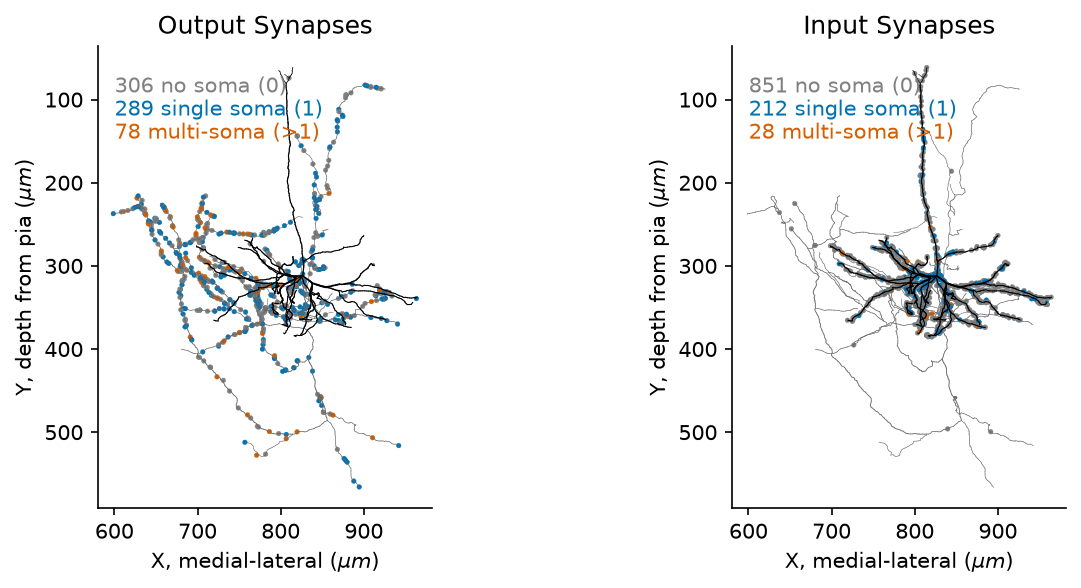

In [19]:
# Figure 3: Skeleton with inputs and outputs, filtered by 'known' connections

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

point_size = 5
soma_palette = {
    "no soma (0)":     "grey",
    "single soma (1)": "#0072B2",   # blue
    "multi-soma (>1)": "#D55E00",   # vermillion — the category that corrupts analysis
}
soma_order = ["no soma (0)", "single soma (1)", "multi-soma (>1)"]

for i in range(2):
    osy.plot.plot_morphology_2d(cell_um,
                                projection="xy",
                                color="compartment",
                                palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "dimgrey"},
                                linewidth="radius",
                                linewidth_norm=(100, 1000),
                                widths=(0.25, 2),
                                ax=ax[i])
# Output synapses
sns.scatterplot(data=output_df, x="syn_x_um", y="syn_y_um", legend=False,
                s=point_size, hue="soma_class", palette=soma_palette, hue_order=soma_order,
                ax=ax[0], edgecolor=None)

# Input synapses
sns.scatterplot(data=input_df, x="syn_x_um", y="syn_y_um", legend=False,
                s=point_size, hue="soma_class", palette=soma_palette, hue_order=soma_order,
                ax=ax[1], edgecolor=None)

for j, label in enumerate(soma_order):
    n = (output_df["soma_class"] == label).sum()
    ax[0].text(0.05, 0.9 - 0.05 * j, f"{n} {label}",
            color=soma_palette[label], transform=ax[0].transAxes)
for j, label in enumerate(soma_order):
    n = (input_df["soma_class"] == label).sum()
    ax[1].text(0.05, 0.9 - 0.05 * j, f"{n} {label}",
            color=soma_palette[label], transform=ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
ax[1].set(title="Input Synapses", xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
sns.despine()
plt.show()

#### Which partners do we actually know?

We can confidently assign synaptic partners **only when `n_soma==1`**. 

There is an asymmetry here that is worth dwelling on: we know about 40% `289/(289+306+78)` of postsynaptic partners to this neuron, and 20% `212/(212+28+851)` presynaptic partners. These reflect different categories of unknowns.

For connectivity analysis, we generally takes a conservative approach drops all multi-soma objects as 'unknowns'.

#### Explicit proofreading status

In addition, we keep a list of which cells in the dataset have undergone **comprehensive proofreading** such that their axon outputs are trustworthy. Our example cell is proofread, which we can see with:

In [20]:
client.materialize.tables.proofreading_status_and_strategy(pt_root_id=root_id).query(
    select_columns=['pt_root_id','status_dendrite','status_axon','strategy_dendrite','strategy_axon']
)

,pt_supervoxel_id,pt_root_id,status_dendrite,status_axon,strategy_dendrite,strategy_axon
0,92829912045986361,864691132534315610,True,True,dendrite_extended,axon_fully_extended


We add proofreading status of the input axon as an explicit category

In [21]:
prf_axon_ids = set(
    client.materialize.tables.proofreading_status_and_strategy(status_axon=True)
    .query(select_columns=["pt_root_id"])["pt_root_id"]
)

# declared before it can be assigned into a Categorical
input_df["partner_class"] = input_df["soma_class"].cat.add_categories("axon proofread")
input_df.loc[input_df["pre_pt_root_id"].isin(prf_axon_ids), "partner_class"] = "axon proofread"

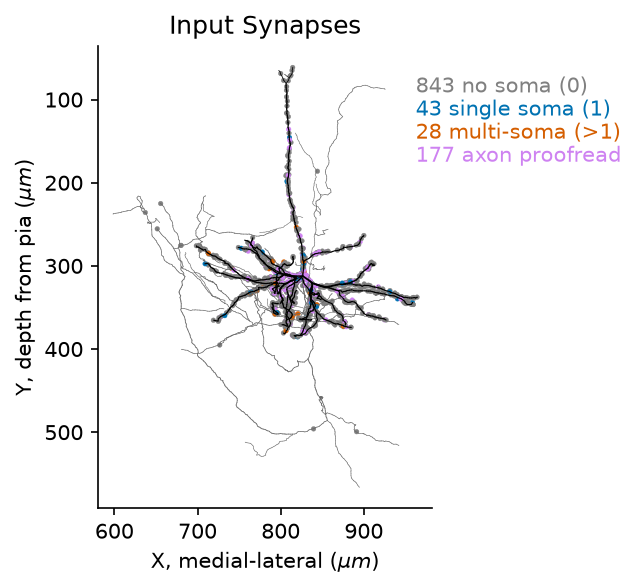

In [22]:
# Figure 4: Skeleton with inputs and outputs, filtered by 'known' connections

fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=150)

point_size = 5
partner_palette = {
    "no soma (0)":     "grey",
    "single soma (1)": "#0072B2",   # blue
    "axon proofread":  "#CE82F1",   # lavender
    "multi-soma (>1)": "#D55E00",   # vermillion — the category that corrupts analysis
}
partner_order = ["no soma (0)", "single soma (1)", "multi-soma (>1)", "axon proofread"]


osy.plot.plot_morphology_2d(cell_um,
                            projection="xy",
                            color="compartment",
                            palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "dimgrey"},
                            linewidth="radius",
                            linewidth_norm=(100, 1000),
                            widths=(0.25, 2),
                            ax=ax)


# Input synapses
sns.scatterplot(data=input_df, x="syn_x_um", y="syn_y_um", legend=False,
                s=point_size, hue="partner_class", palette=partner_palette, hue_order=soma_order,
                ax=ax, edgecolor=None)


for j, label in enumerate(partner_order):
    n = (input_df["partner_class"] == label).sum()
    ax.text(.95, 0.9 - 0.05 * j, f"{n} {label}",
            color=partner_palette[label], transform=ax.transAxes)

ax.set(title="Input Synapses", xlabel=r'X, medial-lateral ($\mu m$)', ylabel=r'Y, depth from pia ($\mu m$)')
sns.despine()
plt.show()

This is a smaller 10% `117/(117+43+28+851)` of inputs that we trust. 

Every one of those grey input points is a synapse that (probably) genuinely happened. What's missing is the partner's identity, and beyond that, how many other synapses that partner made. So inputs will tell you what lands on this cell and where; only the proofread subset supports "how strongly is A connected to B" or any connection-probability statement. 

This is the critical point when framing analysis: what is your denominator for comparison? Is it all neurons? All single-soma neurons? All proforead neurons? The right answer depends on your question. 
Module 2 this afternoon will restrict to proofread cohorts, which is a safe but conservative framing.

## Morphological cell types

![Morphological cell types](img/neuron_rogues_gallery.png) 

Identifying the putative ‘cell type’ from the EM morphology is a process that involves both manual and automatic classifications. Subsets of the dataset have been manually classified by anatomists at the Allen Institute, and these ground truth labels used to train and refine different automated ‘feature classifiers’ over time.

The diversity of manual and automated cell type classifications available in the dataset reflect the fact that definitions of ‘cell types’ in the dataset is an active area of research and must be contextualized against the purpose and resolution of the cell-typing being performed.

Two of the most predictive features for broad cell type are:

* Soma location (in units of depth from pial surface). This captures cortical layer diversity
* Soma size (in units of volume). This is a strong proxy of many types of cell morpholigical diversity

For this, we will grab the soma information like we did before, but explicitly include `volume`. This is a measurement of the **nucleus volume in cubic microns**:

In [23]:
# CAVEquery the nucleus lookup table
soma_df= client.materialize.views.nucleus_alternative_lookup().query(
    select_columns = ['id','pt_root_id','pt_position','volume'],
    desired_resolution = [1,1,1],
).rename(columns={"volume": "nucleus_volume"})

# Data cleaning: annotate the duplicates on `pt_root_id`. n_soma>1 are 'multi-soma' objects make interpretation difficult.
soma_counts = (
    soma_df.groupby("pt_root_id")["id"].nunique().rename("n_soma").reset_index()
)

# desired_resolution=[1,1,1] means the positions come back in nanometres, so the same
# transform we used on the synapses applies here unchanged — depth in microns below pia.
soma_df["depth_um"] = tform.apply_dataframe("pt_position", soma_df, projection="y")

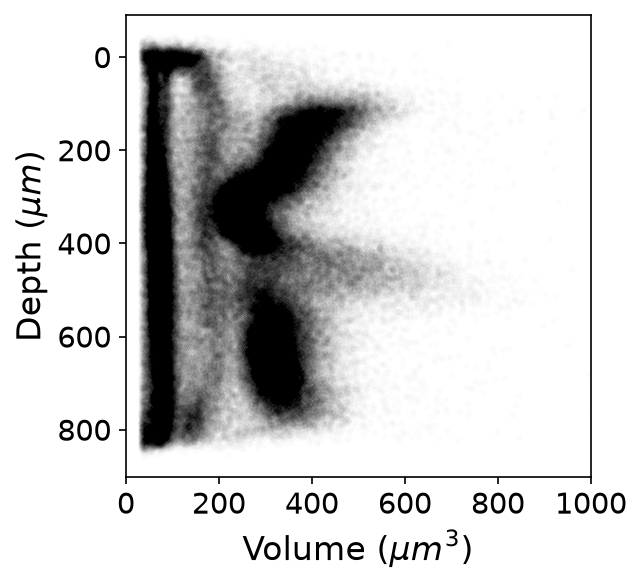

In [ ]:
# Figure 5: Spatial Organization of Cell Nuclei in the tissue

# Plot cell volume by depth
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)
sns.scatterplot(
    data=soma_df,
    x="nucleus_volume",
    y="depth_um",
    s=8,          # marker size. `size=` would ask seaborn for a size *variable*
    edgecolor=None,
    alpha=0.01,
    color="k",
    ax=ax,
    legend=False,
)
ax.invert_yaxis()
ax.set_xlabel(r"Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel(r"Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 1000)
plt.show()

### Using the automated cell types

Many of these automated cell type definitions were established and refined for the [MICrONS Dataset](https://www.microns-explorer.org/) including:

<ul>
    <li> Perisomatic cell features <a href=https://www.nature.com/articles/s41586-024-07765-7>(Elabbady et al.)</a> </li>
    <li> Morphology and connectivity features <a href=https://www.nature.com/articles/s41586-024-07780-8>(Schneider-Mizell et al.)</a> </li>

The process of applying these labels to the V1DD dataset is ongoing, but we will use cell typing from the <code>cell_type_multifeature_v1</code> table which labels cell types according to using soma, nucleus, dendrite, and spine features. 
</ul>

Excitatory neurons are labeled by projection category (IT, ET, NP, CT, and SP for subplate). 

Inhibitory neurons follow labels based on targeting such as ITC (inhibitory targeting), STC (sparsely targeting), PTC (perisomatic targeting), and DTC (dendrite targeting), but might align more with molecular class than exact targeting for a given neuron, particularly among ITC/VIP cells.

*Note:* Cells here without a label are null and will disappear. These are either non-neuronal cells or potential neurons with `n_soma!=1`

In [25]:
cell_type_df = client.materialize.tables.cell_type_multifeature_v1().query(
    desired_resolution=[1, 1, 1], 
    split_positions=True,
).rename(columns={"classification_system": "cell_type_coarse",})


# add to our soma_df on nucleus id
soma_cell_type_df = soma_df.merge(cell_type_df[['id','cell_type','cell_type_coarse']], on='id', how='left')

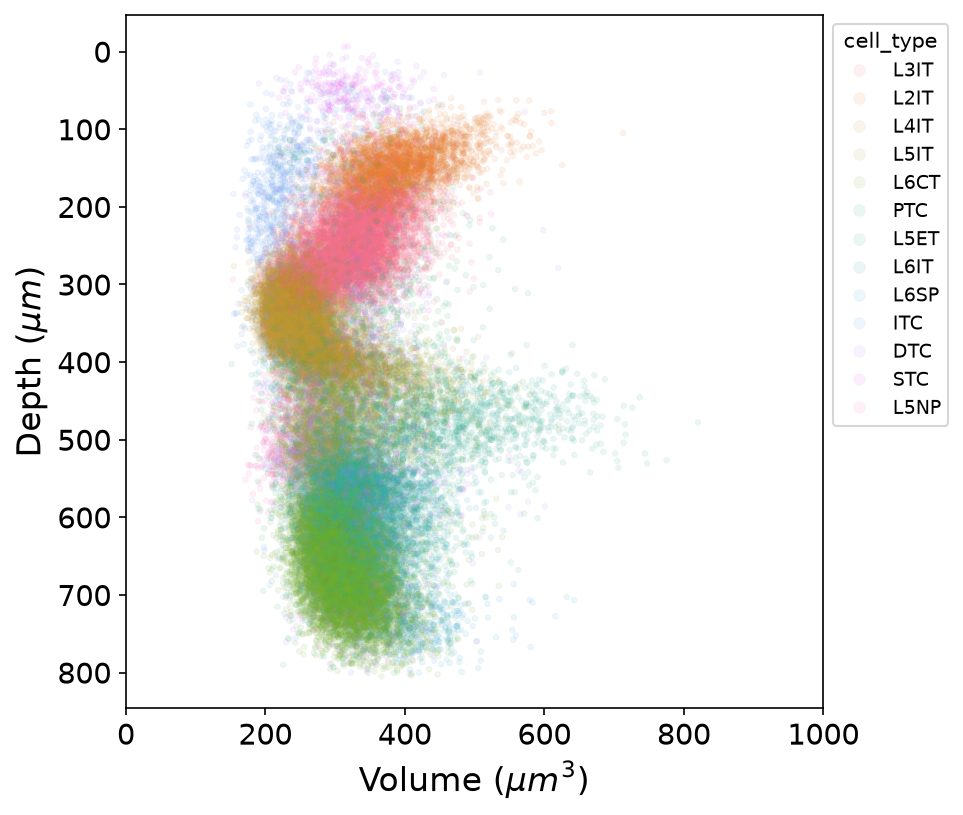

In [26]:
# Figure 6: The same cells, coloured by automated cell type

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)

# Color hue by cell_type 
sns.scatterplot(
    data=soma_cell_type_df,
    x="nucleus_volume",
    y="depth_um",
    s=8,
    edgecolor=None,
    alpha=0.1,
    color="k",
    ax=ax,
    legend=True,
    hue="cell_type",
)
ax.invert_yaxis()
ax.set_xlabel(r"Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel(r"Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 1000)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize=9, markerscale=2)
plt.show()

#### Exercise 4: Separate inhibitory and excitatory classes 

Separate this plot by inhibitory and excitatory classes (hint: `cell_type_coarse`), as two subplots

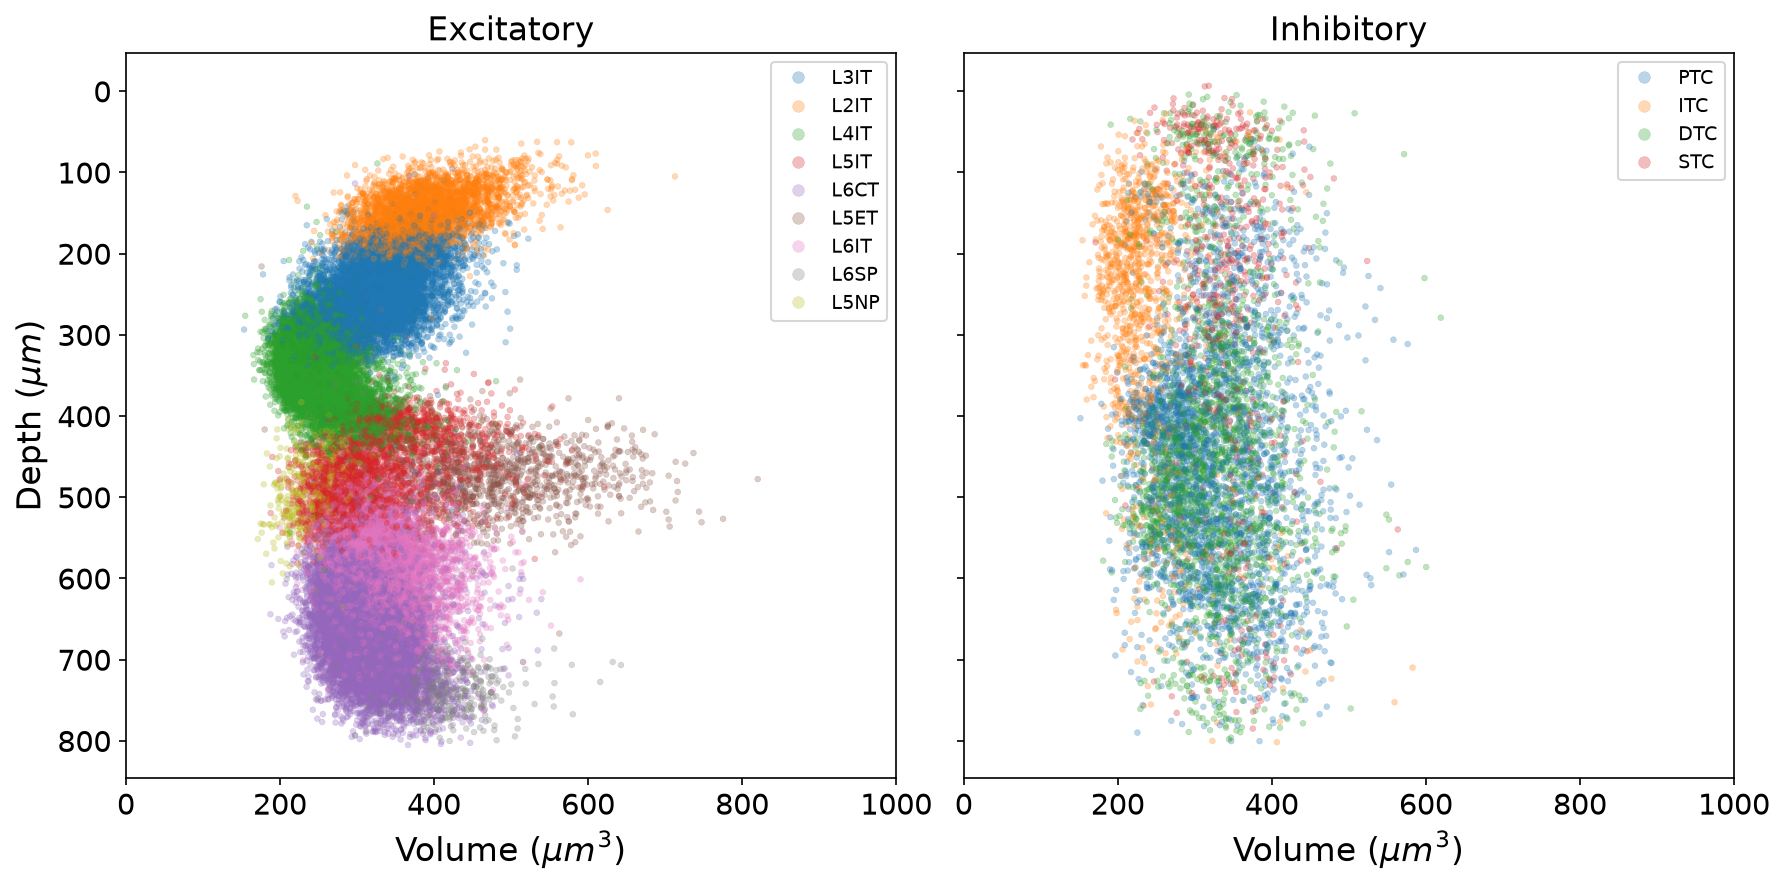

In [27]:
# Figure 7: Excitatory and inhibitory cells separated

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=150, sharex=True, sharey=True)

# 'excitatory' and 'inhibitory' are the coarse labels; cells with no label are None and drop out of the query
for ax, coarse, title in zip(axes, ["excitatory", "inhibitory"], ["Excitatory", "Inhibitory"]):
    sns.scatterplot(
        data=soma_cell_type_df.query("cell_type_coarse == @coarse"),
        x="nucleus_volume",
        y="depth_um",
        s=8,
        edgecolor=None,
        alpha=0.3,
        hue="cell_type",
        ax=ax,
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0, 1000)
    ax.set_xlabel(r"Volume ($\mu m^3$)", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.legend(fontsize=9, markerscale=2)

# sharey=True, so inverting one axis inverts both
axes[0].invert_yaxis()
axes[0].set_ylabel(r"Depth ($\mu m$)", fontsize=16)


plt.tight_layout()
plt.show()

### Gallery of cell types

Depth and soma volume separate the broad classes, but they do not show you what a cell
type *is*. The clearest way to see that is to put the morphologies side by side and let
the shapes make the argument.


In [ ]:
gallery_ids = {
    "L2-IT":      864691132546426513,   # excitatory, superficial, apical dendrite to pia
    "L5-ET":      864691132596046903,   # excitatory, deep, thick apical trunk
    "Martinotti": 864691132562471396,   # inhibitory, ascending axon arborising in L1
    "Basket":     864691132586288610,   # inhibitory, dense perisomatic axon near the soma
    "Bipolar":    864691132544823185,   # inhibitoary, narrow bitufted arbor (VIP/ITC)
}

gallery_dict = {}

for (label, gallery_root_id) in gallery_ids.items():

    gallery_dict[label] = osy.load_cell_from_client(
            root_id=gallery_root_id,
            client=client,
        ).transform(tform.apply)


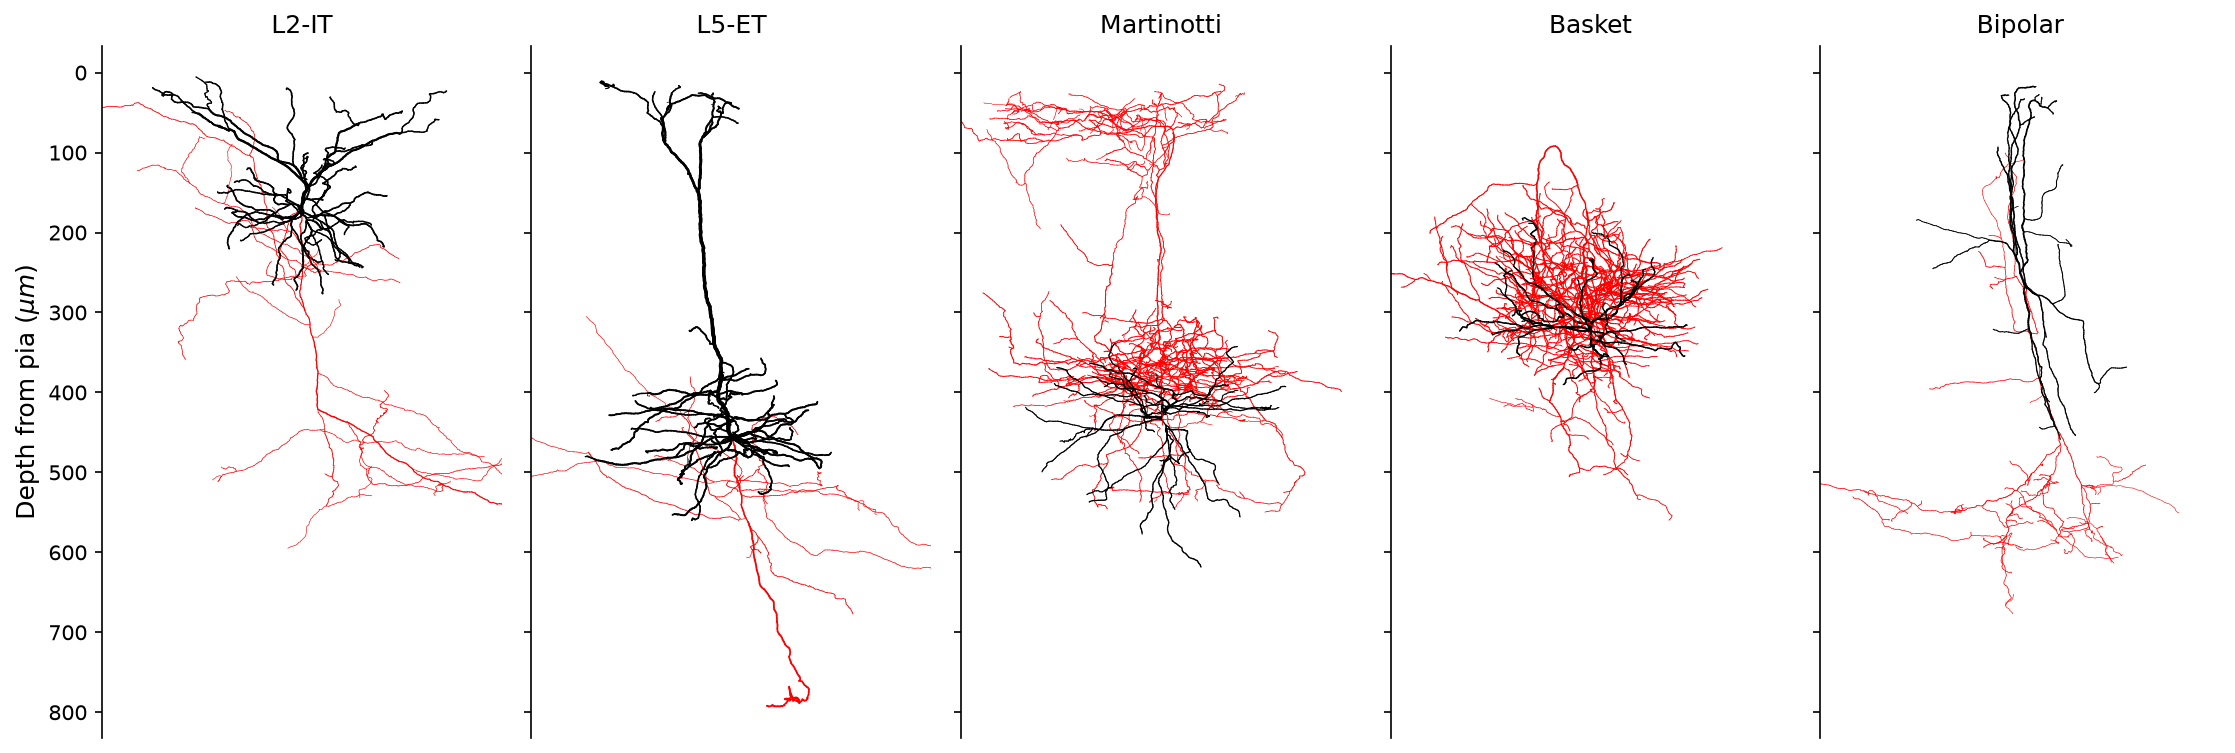

CPU times: user 40.6 s, sys: 508 ms, total: 41.1 s
Wall time: 1min 38s


In [ ]:
%%time
# Figure 8: A gallery of morphological cell types



# The same horizontal span in every panel. Depth is shared and left in true pial coordinates
HALF_WIDTH_UM = 250

fig, axes = plt.subplots(1, 5, figsize=(15, 6), dpi=150, sharey=True)

for ax, (label, gallery_root_id) in zip(axes, gallery_ids.items()):
    if gallery_root_id is None:
        ax.set_title(f"{label}\n(root_id needed)", fontsize=10, color="grey")
        ax.set_axis_off()
        continue

    # # No synapses: the gallery is about shape, and skipping them loads much faster
    # gallery_cell = osy.load_cell_from_client(
    #     root_id=gallery_root_id,
    #     client=client,
    # ).transform(tform.apply)
    gallery_cell = gallery_dict[gallery_root_id]

    osy.plot.plot_morphology_2d(
        gallery_cell,
        projection="xy",
        color="compartment",
        palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
        linewidth="radius",
        linewidth_norm=(100, 1000),
        widths=(0.25, 2),
        ax=ax,
    )

    # Centre each panel on its own soma so the arbors are comparable side by side
    soma_x = gallery_cell.s.root_location[0]
    ax.set_xlim(soma_x - HALF_WIDTH_UM, soma_x + HALF_WIDTH_UM)
    ax.set_title(label, fontsize=12)
    ax.set_xticks([])
    ax.set_xlabel("")

axes[0].set_ylabel(r"Depth from pia ($\mu m$)", fontsize=12)
sns.despine(bottom=True)
plt.tight_layout()
plt.show()

## Interactive session in neuroglancer

Navigation Instructions in the [DataBook: Neuroglancer](https://allenswdb.github.io/anatomy/microns-em/em-neuroglancer.html).

**V1DD Neuroglancer Explorer**: 

> Cell Type Segment Properties : <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6528485848776704>

You will be prompted for a google login. Use the same account you used to authenticate your CAVE token


**Bonus Neuroglancer links**:

> Proofreading Status Segment Properties: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5293734357893120>
>
> Cell type filtered by axon status: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5848621518422016>
> 
> Synapses with spine/shaft/soma labels (can be slow to load): <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5867245166133248>

